In [1]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

# Load clean dataset
df = pd.read_csv('container_shipments_2024_clean.csv')

# Reconvert date columns
date_cols = ['booking_date', 'etd', 'atd', 'eta', 'ata']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=True, errors='coerce')

# Reconvert integer columns
df['transit_days'] = df['transit_days'].astype('Int64')
df['delay_days'] = df['delay_days'].astype('Int64')

print(f"Records: {len(df)}")
print(f"Columns: {df.shape[1]}")
print("Dataset ready.")

Saving container_shipments_2024_clean.csv to container_shipments_2024_clean.csv
Records: 3531
Columns: 28
Dataset ready.


In [2]:
status_dist = df['status'].value_counts()
status_pct = df['status'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'count': status_dist,
    'percentage': status_pct.round(1)
})

print(summary)

            count  percentage
status                       
Delivered    1752        49.6
Cancelled    1212        34.3
In Transit    328         9.3
Delayed       239         6.8


In [3]:
carrier_dist = df[df['status'] != 'Cancelled']['carrier'].value_counts()
carrier_pct = df[df['status'] != 'Cancelled']['carrier'].value_counts(normalize=True) * 100

carrier_summary = pd.DataFrame({
    'count': carrier_dist,
    'percentage': carrier_pct.round(1)
})

print(carrier_summary)

             count  percentage
carrier                       
Maersk        1043        45.0
Hapag-Lloyd    598        25.8
MSC            389        16.8
CMA CGM        289        12.5


In [4]:
df['route'] = df['port_origin'] + ' → ' + df['port_destination']

route_dist = df[df['status'] != 'Cancelled']['route'].value_counts()
route_pct = df[df['status'] != 'Cancelled']['route'].value_counts(normalize=True) * 100

route_summary = pd.DataFrame({
    'count': route_dist,
    'percentage': route_pct.round(1)
})

print(route_summary)

                                  count  percentage
route                                              
Jacksonville, FL → Santos, BR       802        34.6
Port Everglades, FL → Santos, BR    779        33.6
Houston, TX → Santos, BR            738        31.8


In [5]:
df_active = df[df['status'] != 'Cancelled'].copy()

monthly = df_active.groupby('month')['shipment_id'].count().reset_index()
monthly.columns = ['month', 'shipment_count']
monthly['month_name'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%b')

print(monthly[['month_name', 'shipment_count']])

   month_name  shipment_count
0         Jan             205
1         Feb             191
2         Mar             201
3         Apr             186
4         May             204
5         Jun             188
6         Jul             199
7         Aug             208
8         Sep             194
9         Oct             185
10        Nov             199
11        Dec             159


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

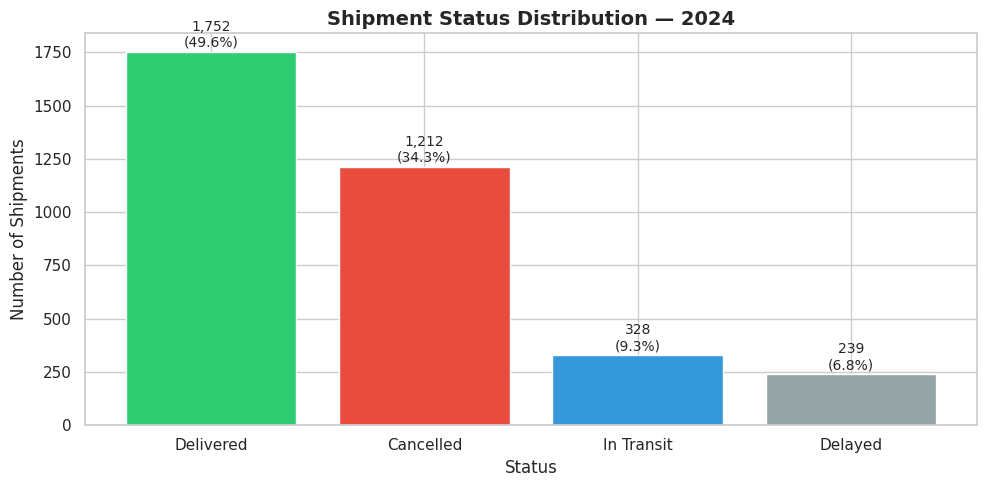

In [8]:
fig, ax = plt.subplots()

colors = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']

ax.bar(summary.index, summary['count'], color=colors)

ax.set_title('Shipment Status Distribution — 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Number of Shipments')

# Add value labels on top of each bar
for bar, (count, pct) in zip(ax.patches, zip(summary['count'], summary['percentage'])):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{count:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

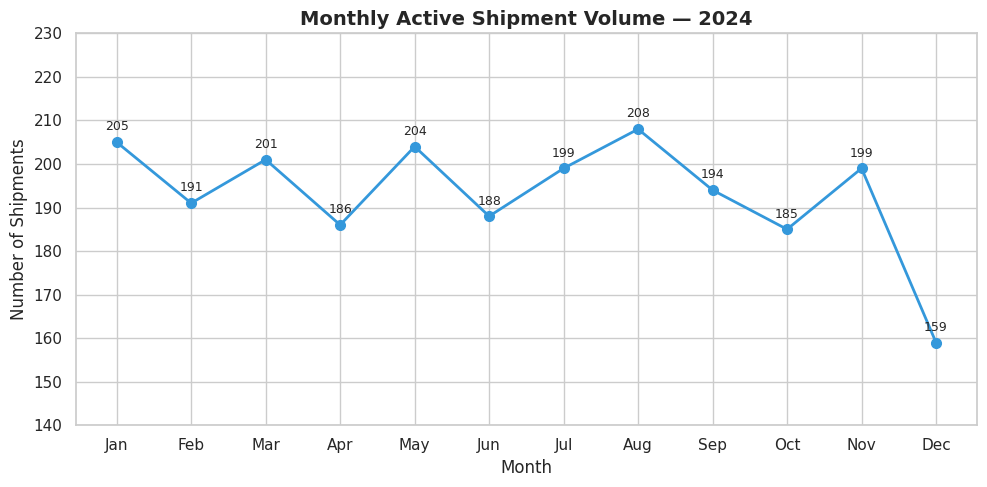

In [9]:
fig, ax = plt.subplots()

ax.plot(monthly['month_name'], monthly['shipment_count'],
        marker='o', linewidth=2, color='#3498db', markersize=7)

ax.set_title('Monthly Active Shipment Volume — 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Shipments')

# Add value labels on each point
for i, row in monthly.iterrows():
    ax.text(i, row['shipment_count'] + 2, str(row['shipment_count']),
            ha='center', va='bottom', fontsize=9)

# Set y-axis range for better visibility
ax.set_ylim(140, 230)

plt.tight_layout()
plt.show()

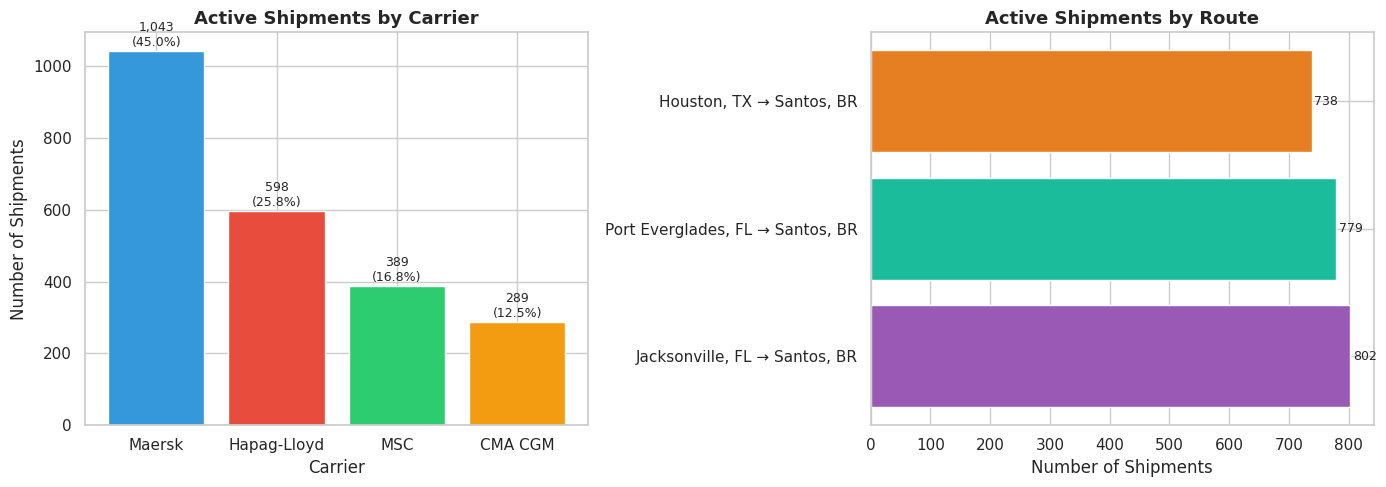

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: By carrier
carrier_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
axes[0].bar(carrier_summary.index, carrier_summary['count'], color=carrier_colors)
axes[0].set_title('Active Shipments by Carrier', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Carrier')
axes[0].set_ylabel('Number of Shipments')

for bar, (count, pct) in zip(axes[0].patches, zip(carrier_summary['count'], carrier_summary['percentage'])):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{count:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=9
    )

# Chart 2: By route
route_colors = ['#9b59b6', '#1abc9c', '#e67e22']
axes[1].barh(route_summary.index, route_summary['count'], color=route_colors)
axes[1].set_title('Active Shipments by Route', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Shipments')

for bar, count in zip(axes[1].patches, route_summary['count']):
    axes[1].text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}',
        ha='left', va='center', fontsize=9
    )

plt.tight_layout()
plt.show()

In [11]:
print(f"Records: {len(df)}")
print(f"Columns: {df.shape[1]}")
print(f"\nActive shipments: {len(df[df['status'] != 'Cancelled'])}")
print(f"\nCarriers: {df['carrier'].unique()}")
print(f"Container types: {df['container_type'].unique()}")
print(f"\nDate types OK: {df['ata'].dtype}")

Records: 3531
Columns: 29

Active shipments: 2319

Carriers: ['Hapag-Lloyd' 'CMA CGM' 'MSC' 'Maersk']
Container types: ['40HC' '40ST']

Date types OK: datetime64[ns]


In [12]:
df_completed = df[df['status'].isin(['Delivered', 'Delayed'])]

In [13]:
print(f"Completed shipments: {len(df_completed)}")

Completed shipments: 1991


In [14]:
on_time_pct = (df_completed['on_time'].sum() / len(df_completed)) * 100

In [15]:
print(on_time_pct)

42.591662481165244


In [16]:
print(df_completed['on_time'].value_counts())
print(df_completed['on_time'].isna().sum())

on_time
False    1143
True      848
Name: count, dtype: int64
0


In [17]:
print(df_completed['delay_days'].describe())
print(f"\nDelay distribution:")
print(df_completed['delay_days'].value_counts().sort_index())

count       1991.0
mean      2.823204
std      26.628316
min         -321.0
25%            0.0
50%            1.0
75%            2.0
max          324.0
Name: delay_days, dtype: Float64

Delay distribution:
delay_days
-321    1
-292    1
-265    1
-207    1
-179    1
       ..
265     1
274     1
294     1
296     1
324     1
Name: count, Length: 65, dtype: Int64


In [18]:
valid = df_completed[(df_completed['delay_days'] >= -7) & (df_completed['delay_days'] <= 21)]
invalid = df_completed[(df_completed['delay_days'] < -7) | (df_completed['delay_days'] > 21)]

print(f"Valid records: {len(valid)}")
print(f"Invalid records: {len(invalid)}")
print(f"Invalid percentage: {len(invalid)/len(df_completed)*100:.1f}%")

Valid records: 1938
Invalid records: 53
Invalid percentage: 2.7%


In [19]:
df_completed = valid.copy()
print(f"Final completed shipments: {len(df_completed)}")

Final completed shipments: 1938


In [20]:
on_time_pct = (df_completed['on_time'].sum() / len(df_completed)) * 100

In [21]:
print(on_time_pct)

42.77605779153767


In [22]:
df_completed['on_time'] = df_completed['delay_days'] <= 2

on_time_pct = (df_completed['on_time'].sum() / len(df_completed)) * 100
delayed_pct = 100 - on_time_pct

print(f"On-time rate: {on_time_pct:.1f}%")
print(f"Delayed rate: {delayed_pct:.1f}%")

On-time rate: 87.9%
Delayed rate: 12.1%


In [23]:
on_time_per_route = df_completed.groupby('route')['on_time'].mean() * 100

route_performance = pd.DataFrame({
    'on_time_rate': on_time_per_route.round(1),
    'delayed_rate': (100 - on_time_per_route).round(1)
})

print(route_performance.sort_values('delayed_rate', ascending=False))

                                  on_time_rate  delayed_rate
route                                                       
Jacksonville, FL → Santos, BR             87.6          12.4
Port Everglades, FL → Santos, BR          88.0          12.0
Houston, TX → Santos, BR                  88.2          11.8


In [24]:
total_per_route = df_completed.groupby('route')['shipment_id'].count()
on_time_per_route_count = df_completed.groupby('route')['on_time'].sum()

route_counts = pd.DataFrame({
    'total': total_per_route,
    'on_time': on_time_per_route_count,
    'delayed': total_per_route - on_time_per_route_count
})

print(route_counts.sort_values('delayed', ascending=False))

                                  total  on_time  delayed
route                                                    
Jacksonville, FL → Santos, BR       661      579       82
Port Everglades, FL → Santos, BR    667      587       80
Houston, TX → Santos, BR            610      538       72


In [25]:
print(f"df shape: {df.shape}")
print(f"df_completed records: {len(df_completed)}")
print(f"On-time rate: {(df_completed['on_time'].sum() / len(df_completed)) * 100:.1f}%")
print(f"Carriers: {df_completed['carrier'].unique()}")

df shape: (3531, 29)
df_completed records: 1938
On-time rate: 87.9%
Carriers: ['CMA CGM' 'MSC' 'Hapag-Lloyd' 'Maersk']


In [26]:
eta_ata_by_carrier = df_completed.groupby('carrier')['delay_days'].agg(['mean', 'median', 'std']).round(2)
eta_ata_by_carrier.columns = ['mean_delay', 'median_delay', 'std_delay']
print(eta_ata_by_carrier.sort_values('median_delay', ascending=False))

             mean_delay  median_delay  std_delay
carrier                                         
CMA CGM            1.31           1.0       3.05
Hapag-Lloyd        1.53           1.0       3.24
MSC                1.65           1.0       3.42
Maersk             1.66           1.0       3.42


/tmp/ipykernel_4192/2986951802.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=carriers)


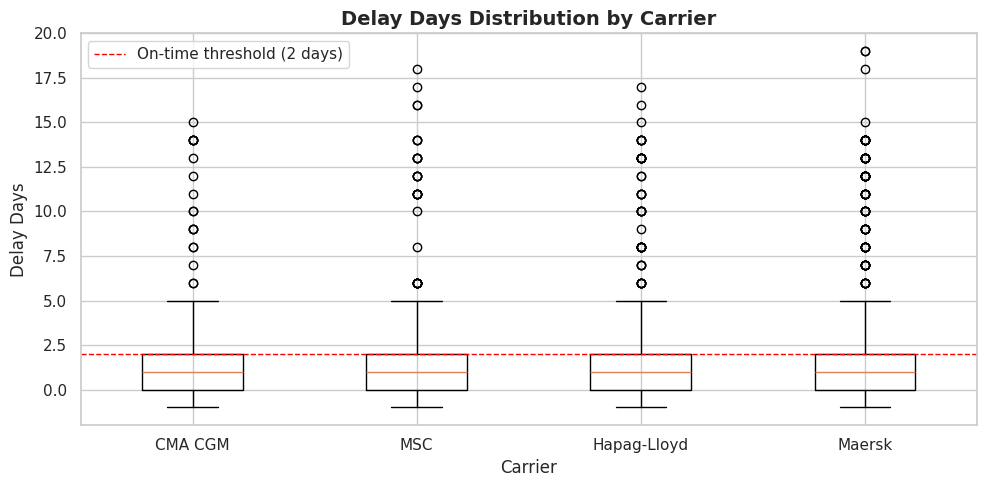

In [27]:
fig, ax = plt.subplots()

carriers = df_completed['carrier'].unique()
data = [df_completed[df_completed['carrier'] == c]['delay_days'].dropna() for c in carriers]

ax.boxplot(data, labels=carriers)
ax.axhline(y=2, color='red', linestyle='--', linewidth=1, label='On-time threshold (2 days)')
ax.set_title('Delay Days Distribution by Carrier', fontsize=14, fontweight='bold')
ax.set_xlabel('Carrier')
ax.set_ylabel('Delay Days')
ax.legend()

plt.tight_layout()
plt.show()

In [29]:
df_active = df[df['status'] != 'Cancelled'].copy()

incident_dist = df_active[df_active['incident_type'] != '']['incident_type'].value_counts()
incident_pct = df_active[df_active['incident_type'] != '']['incident_type'].value_counts(normalize=True) * 100

incident_summary = pd.DataFrame({
    'count': incident_dist,
    'percentage': incident_pct.round(1)
})

print(incident_summary)

                          count  percentage
incident_type                              
Port congestion              78        23.1
Weather delay                65        19.2
Documentation issue          54        16.0
Customs hold                 51        15.1
Equipment unavailability     47        13.9
Carrier overbooking          43        12.7


In [30]:
total_incidents = incident_summary['count'].sum()
print(f"Total incidents: {total_incidents}")
print(f"Incident rate: {total_incidents / len(df_active) * 100:.1f}%")

Total incidents: 338
Incident rate: 14.6%


In [33]:
# Total active shipments per carrier
total_per_carrier = df_active.groupby('carrier')['shipment_id'].count()

# Incidents per carrier
incidents_per_carrier = df_active[df_active['incident_type'] != ''].groupby('carrier')['shipment_id'].count()

# Combine
carrier_incidents = pd.DataFrame({
    'total': total_per_carrier,
    'incidents': incidents_per_carrier,
    'incident_rate': (incidents_per_carrier / total_per_carrier * 100).round(1)
})

print(carrier_incidents.sort_values('incident_rate', ascending=False))

             total  incidents  incident_rate
carrier                                     
CMA CGM        289        289          100.0
Hapag-Lloyd    598        598          100.0
MSC            389        389          100.0
Maersk        1043       1043          100.0


In [34]:
print(df_active['incident_type'].isna().sum())
print(df_active[df_active['incident_type'] == '']['incident_type'].count())

1981
0


In [35]:
# Total active shipments per carrier
total_per_carrier = df_active.groupby('carrier')['shipment_id'].count()

# Incidents per carrier
incidents_per_carrier = df_active[df_active['incident_type'].notna()].groupby('carrier')['shipment_id'].count()

# Combine
carrier_incidents = pd.DataFrame({
    'total': total_per_carrier,
    'incidents': incidents_per_carrier,
    'incident_rate': (incidents_per_carrier / total_per_carrier * 100).round(1)
})

print(carrier_incidents.sort_values('incident_rate', ascending=False))

             total  incidents  incident_rate
carrier                                     
MSC            389         64           16.5
Maersk        1043        152           14.6
Hapag-Lloyd    598         87           14.5
CMA CGM        289         35           12.1


In [36]:
total_per_month = df_active.groupby('month')['shipment_id'].count()

# Incidents per month
incidents_per_month = df_active[df_active['incident_type'].notna()].groupby('month')['shipment_id'].count()

# Combine
month_incidents = pd.DataFrame({
    'total': total_per_month,
    'incidents': incidents_per_month,
    'incident_rate': (incidents_per_month / total_per_month * 100).round(1)
})

print(carrier_incidents.sort_values('incident_rate', ascending=False))

       total  incidents  incident_rate
month                                 
5        204         42           20.6
4        186         35           18.8
6        188         30           16.0
8        208         31           14.9
10       185         27           14.6
11       199         28           14.1
1        205         28           13.7
7        199         26           13.1
9        194         25           12.9
12       159         20           12.6
3        201         25           12.4
2        191         21           11.0


In [37]:
print(month_incidents.sort_values('month'))

       total  incidents  incident_rate
month                                 
1        205         28           13.7
2        191         21           11.0
3        201         25           12.4
4        186         35           18.8
5        204         42           20.6
6        188         30           16.0
7        199         26           13.1
8        208         31           14.9
9        194         25           12.9
10       185         27           14.6
11       199         28           14.1
12       159         20           12.6


In [42]:
total_per_month_by_type = df_active.groupby('month')['shipment_id'].count()

# Incidents per month
incidents_per_month_by_type = df_active[df_active['incident_type'].notna()].groupby(['month', 'incident_type'])['shipment_id'].count()

# Combine
monthly_incidents_by_type = pd.DataFrame({
    'total': total_per_month_by_type,
    'incidents': incidents_per_month_by_type,
    'incident_rate': (incidents_per_month_by_type / total_per_month_by_type * 100).round(1)
})

print(monthly_incidents_by_type.sort_values('incident_rate', ascending=False))

                          total  incidents  incident_rate
(12, Port congestion)       NaN       12.0            7.5
(11, Port congestion)       NaN       15.0            7.5
(10, Port congestion)       NaN       13.0            7.0
(5, Documentation issue)    NaN       11.0            5.4
(9, Port congestion)        NaN       10.0            5.2
...                         ...        ...            ...
8                         208.0        NaN            NaN
9                         194.0        NaN            NaN
10                        185.0        NaN            NaN
11                        199.0        NaN            NaN
12                        159.0        NaN            NaN

[79 rows x 3 columns]


/tmp/ipykernel_4192/526151283.py:7: RuntimeWarning: '<' not supported between instances of 'tuple' and 'int', sort order is undefined for incomparable objects.
  monthly_incidents_by_type = pd.DataFrame({


In [43]:
incidents_by_month_type = df_active[df_active['incident_type'].notna()].groupby(['month', 'incident_type'])['shipment_id'].count().unstack(fill_value=0)

print(incidents_by_month_type)

incident_type  Carrier overbooking  Customs hold  Documentation issue  \
month                                                                   
1                                7             2                    6   
2                                5             1                    2   
3                                4             4                    3   
4                                5             6                    6   
5                                9             5                   11   
6                                7             5                    4   
7                                2             6                    3   
8                                0             6                    9   
9                                2             8                    0   
10                               0             4                    3   
11                               2             1                    4   
12                               0             3   